In [292]:
import re, nltk, bs4
import pandas as pd
import numpy as np
from numpy.linalg import norm
import sklearn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix as csr
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from string import punctuation
from nltk.corpus import stopwords
from collections import defaultdict

In [299]:
input = pd.read_csv('./Dataset.csv')

In [300]:
input[input['sentiment'] == 'positive'] = 0
input[input['sentiment'] == 'negative'] = 1

In [301]:
sentiment = input['sentiment']

In [84]:
## GLOBAL DICTS
## countains overall count of the term among all documents
maximum_per_document = defaultdict(int) # maximum a term occurs in one doc. denominator for first equation
number_docs_containing_term = defaultdict(int) ## How many documents contain a term --> denominator for second equation
stop_words = set(stopwords.words('english'))

# bow_count will clean the input, create sets for every sentence and return a dict {word:count} & int(maximum count per doc)
def bow_count(sentences):
    new_sentence = ''
    sentences = re.sub(r'<\s*br\s*\/s*>', '', sentences)
    sentences = re.sub(r'\n>', ' ', sentences)
    sentences = re.sub(r'\s+', ' ', sentences)
    sentences = re.sub(r'\.+\s*', '.', sentences)
    sentences = re.sub(r'who\'ll', 'who will', sentences)
    sentences = re.sub(r'[IiyouYousheSHE]\'ll', 'i will', sentences)
    sentences = re.sub(r'[wW]ouldn\'t', 'would not', sentences)
    sentences = re.sub(r'[mM]mustn\'t', 'must not', sentences)
    sentences = re.sub(r'[tT]hat\'s', 'that is', sentences)

    for el in sentences:
        if el.isspace() or el.isalpha() or el == '.': #or el.isnumeric():
            new_sentence += el.lower()

    new_sentences = new_sentence.split('.')
    new_sentences = [set(e for e in el.split() if e not in stop_words) for el in new_sentence.split('.')]
    temp_set = set()
    temp_count = defaultdict(int)

    for el in new_sentences:
        for l in el:

            temp_count[l] += 1
            temp_set.add(l)

    doc_max_term_count = [v for k,v in sorted(temp_count.items(), key= lambda x : x[1], reverse=True)][0]

    for term in temp_set:
        number_docs_containing_term[term] += 1

    return temp_count, doc_max_term_count ## returning a list of sets, where every set is a sentence


def get_tf_idf(w,doc_index,NO_OF_ENTRIES):
    tf_idf = {}
    tf = {}

    for k,v in w.items():
        tf[k] = v / maximum_per_document[doc_index]
        ni = number_docs_containing_term[k]
        from math import log
        idf = log(NO_OF_ENTRIES / ni)
        tf_idf[k] = tf[k] * idf

    return tf_idf


def similarity_vector(words, all_word_vector, words_vector):
    doc_vec = all_word_vector.copy()

    for i,word in enumerate(words_vector):
        if word in words:
            doc_vec[i] = 1

    doc_vec_norm = np.linalg.norm(doc_vec)
    doc_vec /= doc_vec_norm

    return doc_vec, all_word_vector, words_vector # which is a vector that is normalized and can be compared to all others

In [145]:
file_path = 'archive/small_DS.csv'

def tf(n=20, source='imdb'):
    # define number of relevant words n
    nltk.download('stopwords')
    punc = list(punctuation)

    if source == 'reuters':
        file_path = './reut.html'

        def extract_reuters_news(path_file):
            file = open(path_file , 'r').read()
            soup = bs4.BeautifulSoup(file)
            all_bodies = [el.text for el in soup.find_all('content')] # replace body with content, otherwise bs4 wont find any body other then main body
            return all_bodies

        data = extract_reuters_news(file_path)
        NO_OF_ENTRIES = len(data)

    if source == 'imdb':
        data = pd.read_csv('./Dataset.csv')
        data = data.iloc[:4000]
        df = data
        NO_OF_ENTRIES = len(data)
        NO_OF_ENTRIES
        data = data.review.iloc[:NO_OF_ENTRIES]

    
    docs = []
    for i,doc in enumerate(data):
        counted_terms, m = bow_count(doc)
        maximum_per_document[i] = m
        docs.append(counted_terms)

    result = []
    words_vector = set()

    for ind, words in enumerate(docs):
        ranked_words = get_tf_idf(words, ind, NO_OF_ENTRIES)
        top_n = {k:v for k,v in sorted(ranked_words.items(), key=lambda x: (-x[1]) )[:n] }
        result.append(top_n)
        top_set = set([el for el in top_n.keys()])
        words_vector |= top_set

    all_word_vector = np.zeros(len(words_vector))

    ## global list that will then be stacked to sparse matrix
    similarity_to_stack = []

    # iterate over all entries in result (dictonary with n entries of top words)
    for progress,r in enumerate(result):
        stack_vec, all_word_vector, words_vector = similarity_vector(list(r.keys()), all_word_vector, words_vector)
        similarity_to_stack.append(stack_vec)
        if progress%1000 == 0:
            print(progress, ' records analysed.')

    # stack all results similarity vectors to one matrix
    m = csr(np.vstack(similarity_to_stack))
    m.shape

    # print the stacked matrix:
    # m: number of datapoints, n: number of words in all_word_vector
    plt.spy(m, marker='.', markersize=1)

    # create a similarity vector, by multiplying each element with all others
    ref =m .dot(m.T).toarray()

    return ref, data, words_vector, result ,m

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Darke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0  records analysed.
1000  records analysed.
2000  records analysed.
3000  records analysed.


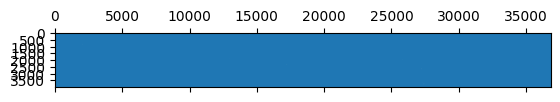

In [147]:
ref,data, words_vector, results,m = tf()

In [297]:
y_train = np.array(sentiment[0:3000],dtype=np.int0)
y_test = np.array(sentiment[3000:4000],dtype=np.int0)

In [288]:
# initialize Naive Bayes
gauss = GaussianNB()
y_pred = gauss.fit(ref[0:3000],y_train).predict(ref[3000:4000])

In [302]:
sklearn.metrics.accuracy_score(y_pred,y_test)*100

62.3

In [ ]:
# initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(m)
clusters = kmeans.labels_

In [213]:
df = pd.DataFrame(data)
df['Cluster'] = clusters

In [214]:
df

,review,Cluster
0,One of the other reviewers has mentioned that ...,0
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,1
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
3995,"Starting off, here's a synopsis: Porno queen A...",1
3996,He pulled the guys guts out his butt! That's a...,1
3997,This movie promised bat people. It didn't deli...,1
3998,"I saw the film many times, and every time I am...",1


In [263]:
total = 0
for i in range(len(clusters)):
    if sentiment[i] == clusters[i]:
        total += 1

In [271]:
(total/len(clusters))*100

70.675

In [304]:
for ind,ary in enumerate(ref):
    for i,el in enumerate(ary):
        if el > 0.6 and ind != i :
            print(ind, ' and ', i)
            break

1328  and  2811
1748  and  3769
2013  and  3537
2811  and  1328
3537  and  2013
3769  and  1748


In [307]:
def test(words_vector, source ='imdb', n=8):
    nltk.download('stopwords')
    punc = list(punctuation)
    stop_words = set(stopwords.words('english'))

    if source == 'reuters':
        file_path = './reut.html'

        def extract_reuters_news(path_file):
            file = open(path_file , 'r').read()
            soup = bs4.BeautifulSoup(file)
            all_bodies = [el.text for el in soup.find_all('content')] # replace body with content, otherwise bs4 wont find any body other then main body
            return all_bodies

        data = extract_reuters_news(file_path)
        NO_OF_ENTRIES = len(data)

    if source == 'imdb':
        data = pd.read_csv('Dataset.csv')
        data = data.iloc[4000:6000]
        NO_OF_ENTRIES = len(data)
        NO_OF_ENTRIES
        data = data.review.iloc[:NO_OF_ENTRIES]

    ## GLOBAL DICTS
    ## countains overall count of the term among all documents
    maximum_per_document = defaultdict(int) # maximum a term occurs in one doc. denominator for first equation
    number_docs_containing_term = defaultdict(int) ## How many documents contain a term --> denominator for second equation

    docs = []
    for i,doc in enumerate(data):
        counted_terms, m = bow_count(doc)
        maximum_per_document[i] = m
        docs.append(counted_terms)

    result = []

    for ind, words in enumerate(docs):
        ranked_words = get_tf_idf(words, ind, NO_OF_ENTRIES)
        top_n = {k:v for k,v in sorted(ranked_words.items(), key=lambda x: (-x[1]) )[:n] }
        result.append(top_n)

    similarity_to_stack = []
    all_word_vector = np.zeros(len(words_vector))

    # iterate over all entries in result (dictonary with n entries of top words)
    for progress,r in enumerate(result):
        stack_vec, all_word_vector, words_vector = similarity_vector(list(r.keys()), all_word_vector, words_vector)
        similarity_to_stack.append(stack_vec)
        if progress%1000 == 0:
            print(progress, ' records analysed.')

    # stack all results similarity vectors to one matrix
    m = csr(np.vstack(similarity_to_stack))
    m.shape

    # print the stacked matrix:
    # m: number of datapoints, n: number of words in all_word_vector
    plt.spy(m, marker='.', markersize=1)

    # create a similarity vector, by multiplying each element with all others
    ref = m.dot(m.T).toarray()

    th=0.8

    for ind,ary in enumerate(ref):
        for i,el in enumerate(ary):
            if el > th and ind != i :
                print(ind, ' and ', i)
                break

    return ref, data

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Darke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0  records analysed.


C:\Users\Darke\AppData\Local\Temp\ipykernel_12192\3517744571.py:65: RuntimeWarning: invalid value encountered in divide
  doc_vec /= doc_vec_norm


1000  records analysed.
1031  and  1908
1388  and  1578
1578  and  1388
1908  and  1031


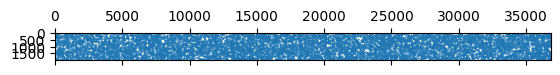

In [308]:
ref_test,data_test = test(words_vector)

In [311]:
print(data_test[4000+1031])

This is a movie about the music that is currently being played in Istanbul. Istanbul was the center of the two Old World superpowers, the Byzantine Empire and the Ottoman Empire. Today, it is a megalopolis of almost 10 million. So it is to no ones surprise that a lot of music is being played in Istanbul, with a great variety of voices, styles, and influences from everywhere on the globe. It is Turkish music, of course, and I was fascinated by Turkish music ever since I bought my first record long time ago. The movie features different singers, instrumentalists and bands. Spoken comments from the musicians nicely illustrate the music being played, and the social context in modern Turkey. For my perspective, the most interesting comments were from Orhan Gencebay. Furthermore, the movies shows urban scenery mainly from Istanbul which is very pleasant to watch.<br /><br />"Crossing the Bridge" is listed as a documentary and it includes music from minorities, e.g. Kurds and Roma. Other impo

In [312]:
print(data_test[4000+1908])

I am very thankful that the small college town of Abingdon, Va.- near Bristol, TN. and home of the famous Barter Theatre where Gregory Peck once acted- managed to get an art film festival togather and show this film there. Abingdon is two and a hour hours from where I live, but the trip was worth it in every sense of the word. UZAK/DISTANT is an amazing, brilliant, jarring, emotional, captivating film. As a Turkish-American, this film was not only a testimony as to what life in Turkey is like; but on a larger scale it tells the world of what it is like to be Turkish whether one lives in Istanbul, Berlin, Montreal, New York, or Omaha. It may be two hours in length as opposed to five minutes, but this is effectively our Bob Marley song. There are so many wonderful scenes in this film. It is very difficult to choose just a random few. But, for me, one telling scene takes place in a Beyoglu (downtown Istanbul) cinema. The title character, played by Mehmet Emin Toprak who sadly died in a ca

T2

In [313]:
print(data_test[4000+1388])

After witnessing his wife (Linda Hoffman) engaging in sexual acts with the pool boy, the already somewhat unstable dentist Dr. Feinstone (Corbin Bernsen) completely snaps which means deep trouble for his patients.<br /><br />This delightful semi-original and entertaining horror flick from director Brian Yuzna was a welcome change of pace from the usual horror twaddle that was passed out in the late Nineties. Although The Dentist' is intended to be a cheesy, fun little film, Yuzna ensures that the movie delivers the shocks and thrills that many more serious movies attempt to dispense. Despite suffering somewhat from the lack of background on the central characters, and thus allowing events that should have been built up to take place over a couple of days, the movie is intriguing, generally well scripted and well paced which allows the viewer to maintain interest, even during the more ludicrous of moments. The Dentist' suffers, on occasion, from dragging but unlike the much inferior 1

In [314]:
print(data_test[4000+1578])

I'm surprised no-one has thought of doing a movie like this before. Horror is often most effective when it uses real life unpleasantness as a theme. And nobody (except for Steve Martin in The Little Shop of Horrors) likes going to the dentist. Tooth torture has been done before (see The Marathan Man for example), but this brings the terror into suburbia.<br /><br />The plot revolves around a dentist, Dr. Alan Feinstone (Corbin Bernsen), who descends into madness. Now our dear doctor wasn't playing with a full deck to begin with, but driven by jealousy and an obsessive-compulsive disorder he begins to reek havoc on those around him. The doctors spiraling mental condition is kinda close to what we see in Micheal Douglas's character in Falling Down, but with a horror edge.<br /><br />Written and directed by horror stalwarts Stuart Gordon and Brian Yuzna, its witty and has a great flow. Also featured playing a cop, is the ever welcome Ken Foree.<br /><br />Now I believe this movie would no